In [73]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [75]:
data = pd.read_csv('./dataset/imdb.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [77]:
le = LabelEncoder()
data['sentiment'] = le.fit_transform(data['sentiment'])

data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [79]:
X_train, X_test, y_train, y_test = train_test_split(data['review'], data['sentiment'], test_size=0.2)

In [81]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

In [85]:
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

X_train = pad_sequences(X_train)
X_test = pad_sequences(X_test)

In [87]:
model = Sequential()
model.add(Embedding(5000, 16))
model.add(GlobalAveragePooling1D())
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [89]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])

In [91]:
model.fit(X_train, y_train, epochs=3)

Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4994 - loss: 0.6937
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5295 - loss: 0.6908
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5821 - loss: 0.6732


In [93]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6233 - loss: 0.6170
Accuracy: 0.6272000074386597


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


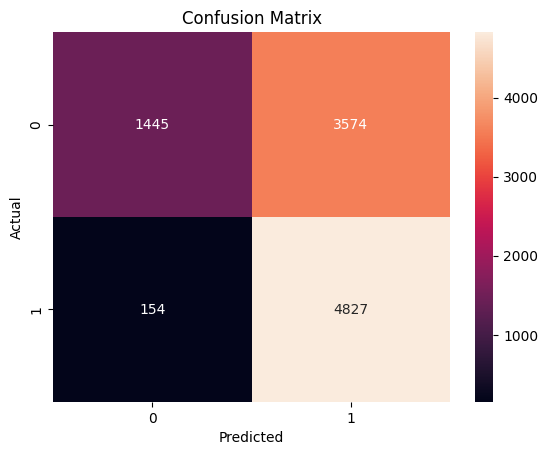


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.29      0.44      5019
           1       0.57      0.97      0.72      4981

    accuracy                           0.63     10000
   macro avg       0.74      0.63      0.58     10000
weighted avg       0.74      0.63      0.58     10000



In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))